### Part B - Text Vectorization and Spam Classification 


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("emails.csv")
print(df.shape)
print(df.head())

(5172, 3002)
  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]


Prediction
0    3672
1    1500
Name: count, dtype: int64


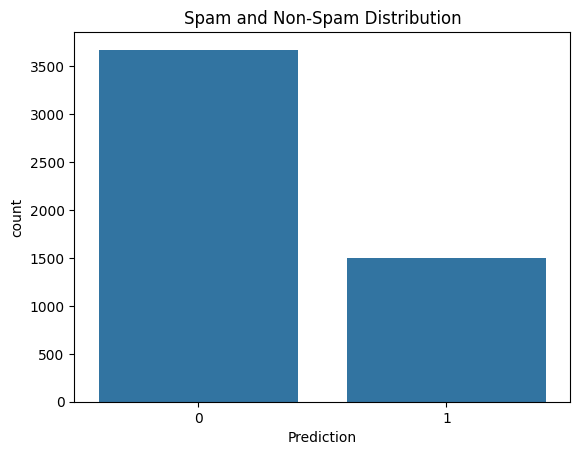

                                          Email_Text  Prediction
0  ect a a is i i s s s as re re e e e e t t t t ...           0
1  the the the the the the the the to to to to to...           0
2  ect a a a a a a a a in in in in on on i i i i ...           0
3  to to to to to ect ect ect ect ect ect ect ect...           0
4  the the the the the the the to to to to to to ...           0


C:\Users\Admin\AppData\Local\Temp\ipykernel_21608\1769324895.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Email_Text"] = df.apply(create_text, axis=1)


In [12]:
print(df["Prediction"].value_counts())

sns.countplot(data=df, x="Prediction")
plt.title("Spam and Non-Spam Distribution")
plt.show()

df = df.dropna(subset=["Prediction"]).copy()
df["Prediction"] = df["Prediction"].astype(int)

feature_cols = [c for c in df.columns if c not in ["Email No.", "Prediction"]]
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

def create_text(row):
    words = []
    for word in feature_cols:
        count = int(max(0, row[word]))
        if count > 0:
            clean_word = re.sub(r"[^a-zA-Z0-9]", "", str(word).lower())
            if clean_word:
                words.extend([clean_word] * min(count, 100))
    return " ".join(words)

df["Email_Text"] = df.apply(create_text, axis=1)
df = df[df["Email_Text"].str.strip() != ""]

print(df[["Email_Text", "Prediction"]].head())

In [13]:
X = df["Email_Text"]
y = df["Prediction"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4137
Testing samples: 1035


In [14]:
count_vectorizer = CountVectorizer(stop_words="english", max_features=10000)

start = time.time()
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)
count_vector_time = time.time() - start

count_model = LogisticRegression(max_iter=1000, class_weight="balanced")
start = time.time()
count_model.fit(X_train_count, y_train)
count_train_time = time.time() - start

start = time.time()
count_pred = count_model.predict(X_test_count)
count_predict_time = time.time() - start

print(classification_report(y_test, count_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       735
           1       0.92      0.97      0.95       300

    accuracy                           0.97      1035
   macro avg       0.96      0.97      0.96      1035
weighted avg       0.97      0.97      0.97      1035



In [15]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english", max_features=10000
)

start = time.time()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
tfidf_vector_time = time.time() - start

tfidf_model = LogisticRegression(max_iter=1000, class_weight="balanced")

start = time.time()
tfidf_model.fit(X_train_tfidf, y_train)
tfidf_train_time = time.time() - start

start = time.time()
tfidf_pred = tfidf_model.predict(X_test_tfidf)
tfidf_predict_time = time.time() - start

print(classification_report(y_test, tfidf_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       735
           1       0.90      0.99      0.94       300

    accuracy                           0.97      1035
   macro avg       0.95      0.97      0.96      1035
weighted avg       0.97      0.97      0.97      1035



In [16]:
comparison = pd.DataFrame({
    "Vectorizer": ["CountVectorizer", "TF-IDF"],
    "Features": [X_train_count.shape[1], X_train_tfidf.shape[1]],
    "Accuracy": [
        accuracy_score(y_test, count_pred),
        accuracy_score(y_test, tfidf_pred)
    ],
    "Precision": [
        precision_score(y_test, count_pred, zero_division=0),
        precision_score(y_test, tfidf_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, count_pred, zero_division=0),
        recall_score(y_test, tfidf_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, count_pred, zero_division=0),
        f1_score(y_test, tfidf_pred, zero_division=0)
    ],
    "Training Time": [count_train_time, tfidf_train_time],
    "Prediction Time": [count_predict_time, tfidf_predict_time]
})

print(comparison.round(4).to_string(index=False))

     Vectorizer  Features  Accuracy  Precision  Recall  F1 Score  Training Time  Prediction Time
CountVectorizer      2738    0.9681     0.9238  0.9700    0.9463         0.1686           0.0009
         TF-IDF      2738    0.9662     0.9003  0.9933    0.9445         0.0522           0.0009


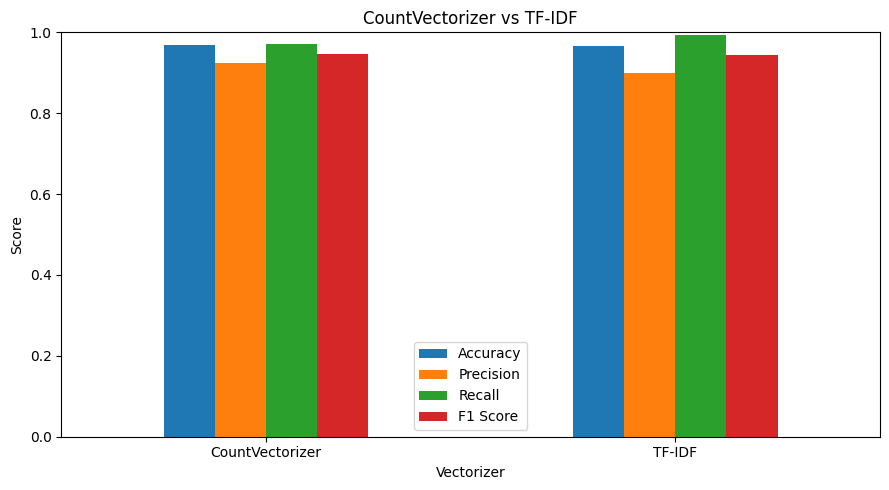

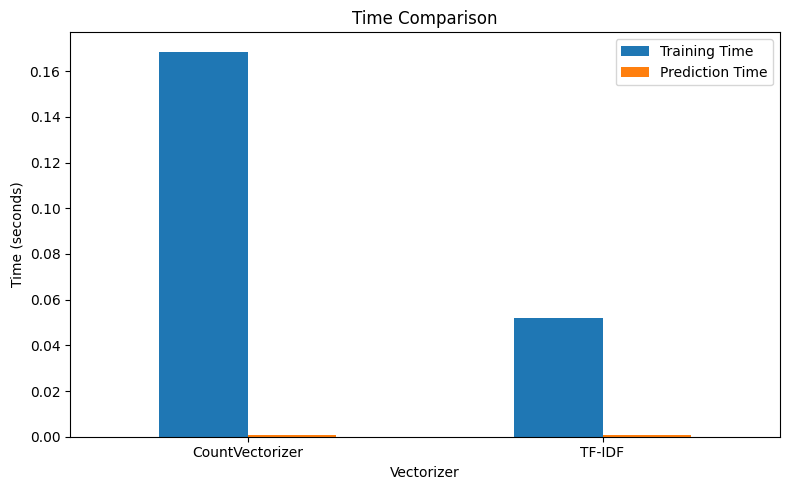

In [17]:
comparison.set_index("Vectorizer")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(kind="bar", figsize=(9, 5), ylim=(0, 1))

plt.title("CountVectorizer vs TF-IDF")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

comparison.set_index("Vectorizer")[
    ["Training Time", "Prediction Time"]
].plot(kind="bar", figsize=(8, 5))

plt.title("Time Comparison")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

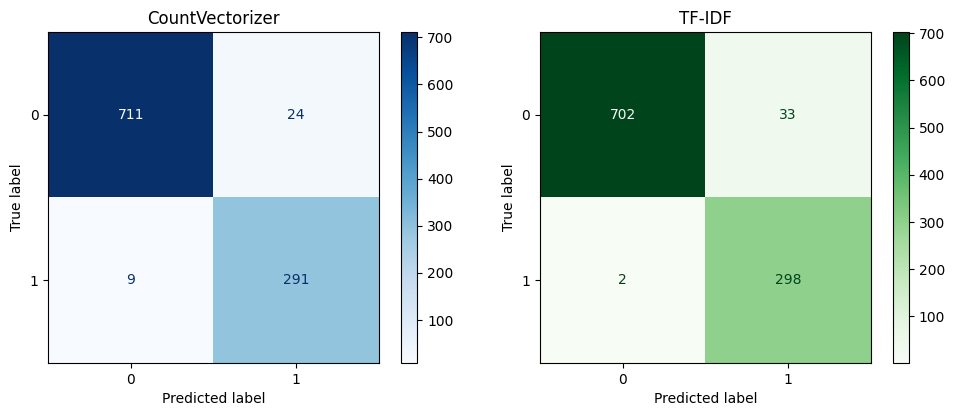

Final Comparison:
     Vectorizer  Features  Accuracy  Precision  Recall  F1 Score  Training Time  Prediction Time
CountVectorizer      2738    0.9681     0.9238  0.9700    0.9463         0.1686           0.0009
         TF-IDF      2738    0.9662     0.9003  0.9933    0.9445         0.0522           0.0009


In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, count_pred, ax=axes[0], cmap="Blues"
)
axes[0].set_title("CountVectorizer")

ConfusionMatrixDisplay.from_predictions(
    y_test, tfidf_pred, ax=axes[1], cmap="Greens"
)
axes[1].set_title("TF-IDF")

plt.tight_layout()
plt.show()

print("Final Comparison:")
print(comparison.round(4).to_string(index=False))

# Task 2: Spam Classification with CountVectorizer vs. TF-IDF

## Dataset and Pipeline

- The dataset has 5,172 emails: 3,672 non-spam and 1,500 spam (roughly 71% vs 29%). The classes are imbalanced, which is why `class_weight="balanced"` was used.
- The data is already a bag-of-words matrix (3,000 word-count columns). The code rebuilds pseudo-text by repeating each word by its count (capped at 100). This works but loses word order, and it is a roundabout way to feed vectorizers that would normally take raw text.
- After stop-word removal, 2,738 features remain (the `max_features=10000` limit is never reached). Some common words like "the", "to" and "and" were removed as stop words, and a few odd tokens ("ect", "hou", "ff") come from the Enron-style corpus.
- The split is 80/20 and stratified: 4,137 training and 1,035 test emails (735 non-spam, 300 spam).

## Results

| Vectorizer | Features | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|
| CountVectorizer | 2738 | 0.9681 | 0.9238 | 0.9700 | 0.9463 |
| TF-IDF | 2738 | 0.9662 | 0.9003 | 0.9933 | 0.9445 |

- Both reach about 97% accuracy, so the choice of vectorizer barely changes overall performance (difference of about 0.2%, or 2 emails).
- The trade-off is in precision and recall. Working back from the metrics, the approximate error counts on the test set are:

| Vectorizer | Missed spam (FN) | False alarms (FP) |
|---|---|---|
| CountVectorizer | ~9 | ~24 |
| TF-IDF | ~2 | ~33 |

- TF-IDF is better if missing spam is the priority (recall 99.3%). CountVectorizer is better if wrongly flagging real emails is the bigger cost (precision 92.4% vs 90.0%). For a real spam filter, false positives (legitimate mail lost) are usually more costly, which slightly favours CountVectorizer.
- F1 is almost identical (0.9463 vs 0.9445), so neither is clearly superior.
- Both models do better on the majority class (non-spam F1 ≈ 0.98) than on spam (≈ 0.94–0.95), as expected with imbalance.

## Efficiency

| Vectorizer | Training Time (s) | Prediction Time (s) |
|---|---|---|
| CountVectorizer | 0.1686 | 0.0009 |
| TF-IDF | 0.0522 | 0.0009 |

- Prediction time is identical.
- TF-IDF trained faster here. This is likely due to the different feature scaling helping the solver converge, but timing differences this small can be noise from a single run.

## Limitations

- Only Logistic Regression was tested. Naive Bayes or a linear SVM are standard for text and could be compared.
- There is no cross-validation or hyperparameter tuning, and the results come from one split.
- The pseudo-text approach means TF-IDF's benefit (downweighting common words) is limited, because the vocabulary was already pre-selected to the 3,000 most frequent words.

## Conclusion

Both vectorizers give about 97% accuracy. The choice shifts the precision/recall balance rather than overall performance: CountVectorizer favours fewer false alarms, TF-IDF favours catching more spam.